# Handling Outliers

Outliers are values that are very different from most other values in a column.

In this notebook, we will learn simple ways to handle outliers in a dataset. We will use the `AveOccup` column from the California Housing dataset.

## What We Will Cover

1. Load the dataset
2. Detect outliers using the IQR method
3. Remove outlier rows
4. Cap outliers using IQR limits
5. Add an outlier flag column
6. Cap values using percentiles
7. Apply log transformation
8. Understand domain-rule handling

## Main Idea

There is no single best outlier treatment for every problem. The correct method depends on the data, the business problem, and whether the extreme values are errors or real observations.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing

In [13]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 1. Dataset Setup

First, we load the California Housing dataset as a pandas DataFrame.

We use a copy of the dataset so the original data remains unchanged. This makes it easier to compare different outlier handling methods.


## 2. Detect Outliers Using IQR

Before handling outliers, we need to identify them.

Here we use the **IQR method**.

IQR means **Interquartile Range**. It measures the spread of the middle 50% of the data.

The common rule is:

- Lower bound = Q1 - 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Any value below the lower bound or above the upper bound is treated as an outlier.


### Detection Observation

We are checking outliers in the `AveOccup` column.

`AveOccup` means the average number of people living in a household for that area.

Very high values can affect analysis and machine learning models because they are far away from normal values.

In the next cells, we create one mask called `iqr_outlier_mask`. This mask tells us which rows are outliers.


In [14]:
# Select the column where outliers will be detected and handled
col = "AveOccup"


# Define a reusable function to calculate IQR lower and upper bounds
def calculate_iqr_bound(data: pd.Series, factor=1.5) -> tuple[float, float]:
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return lower_bound, upper_bound

In [15]:
lower_bound, upper_bound = calculate_iqr_bound(df[col])

# True means the row is an outlier for the selected column
iqr_outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
# Count outliers and calculate their percentage in the dataset
print("lower_bound :", lower_bound)
print("upper_bound :", upper_bound)
print("Outlier count :", iqr_outlier_mask.sum())
print("Outlier percentage :", iqr_outlier_mask.mean() * 100)

lower_bound : 1.1509614824735064
upper_bound : 4.5610405893536905
Outlier count : 711
Outlier percentage : 3.444767441860465


## 3. Treatment 1: Remove Outliers

In this method, we remove rows where `AveOccup` is outside the IQR bounds.

This is simple, but it should be used carefully.

If the outliers are real values, removing them may remove useful information from the dataset.


In [16]:
df_removed = df[iqr_outlier_mask == False]
print("Actual row:", df.shape[0])
print("Rows after Removed:", df_removed.shape[0])
print("No if rows removed :", df.shape[0] - df_removed.shape[0])

Actual row: 20640
Rows after Removed: 19929
No if rows removed : 711


### Removal Observation

After removing outliers, the dataset has fewer rows.

This can make the selected column cleaner, but it also reduces the amount of training data.

Use removal when you are confident that the extreme values are mistakes or not useful for the problem.


## 4. Treatment 2: IQR Capping

Capping means we do not remove rows.

Instead, we limit extreme values to a maximum or minimum allowed value.

In IQR capping:

- Values below the lower bound are replaced with the lower bound.
- Values above the upper bound are replaced with the upper bound.

This keeps all rows in the dataset and reduces the effect of extreme values.


In [17]:
# Use pandas clip() to cap values outside the IQR boundary
# clip() replaces values below the lower limit and above the upper limit with boundary values
df_capping = df.copy()

# For the selected column, cap values to stay between lower_bound and upper_bound
df_capping[col] = df_capping[col].clip(lower_bound, upper_bound)

print("Original Max", df[col].max())
print("Capped Max", df_capping[col].max())

Original Max 1243.3333333333333
Capped Max 4.5610405893536905


### IQR Capping Observation

After capping, the maximum value of `AveOccup` becomes the IQR upper bound.

The row count stays the same because no rows are deleted.

This is useful when we want to reduce the impact of outliers but still keep all records.


## 5. Treatment 3: Add Outlier Flag

Sometimes the outlier itself contains useful information.

Instead of only removing or capping it, we can add a new column that marks whether a row was an outlier.

Here:

- `1` means the row was an outlier.
- `0` means the row was not an outlier.


In [18]:
df_capping[f"{col}_is_outlier"] = iqr_outlier_mask.astype(int)
df_capping.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,AveOccup_is_outlier
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781,0
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771,0
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923,0
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847,0
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894,0


### Outlier Flag Observation

Capping reduces the extreme value, but the flag keeps extra information.

The model can still learn that this row originally had an unusual value.

This method is useful when outliers may have meaning, not just noise.


## 6. Treatment 4: Percentile Capping

Percentile capping uses fixed percentile limits instead of IQR limits.

In this notebook, we use:

- 1st percentile as the lower cap
- 99th percentile as the upper cap

This means very small and very large values are capped, while most values remain unchanged.


In [19]:
# here instead of boundary deciding by IQR, we will decide by ourself
# lower = 0.01 percentile
# upper = 0.99 percentile

lower_cap_value = df[col].quantile(0.01)
higher_cap_value = df[col].quantile(0.99)
print("1st percentile value", lower_cap_value)
print("99th percentile value", higher_cap_value)

1st percentile value 1.5366864723576525
99th percentile value 5.394812032520327


In [ ]:
#  we will use capping in this range
df_percentile_capping = df.copy()
df_percentile_capping[col] = df_percentile_capping[col].clip(
    lower_cap_value, higher_cap_value
)

print("Original min :", df[col].min())
print("Original max :", df[col].max())

print("Capped min :", df_percentile_capping[col].min())
print("Capped max :", df_percentile_capping[col].max())

Original min : 0.6923076923076923
Original max : 1243.3333333333333
Capped min : 1.5366864723576525
Capped max : 5.394812032520327


## 7. Treatment 5: Log Transformation

Log transformation is useful when a column is strongly right-skewed.

Right-skewed data has many normal values and a few very large values.

`np.log1p()` is used here because it safely applies log transformation even when values are close to zero.


<Axes: xlabel='AveOccup', ylabel='Density'>

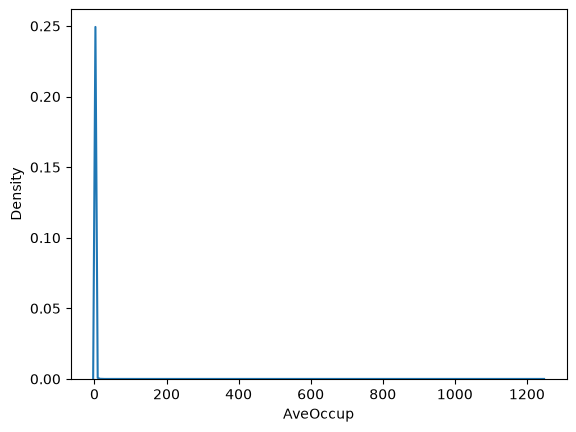

In [ ]:
# log transformation  are good gor right skewed data
sns.kdeplot(df[col])

       AveOccup  log_AveOccup
0      2.555556      1.268511
1      2.109842      1.134572
2      2.802260      1.335596
3      2.547945      1.266369
4      2.181467      1.157342
...         ...           ...
20635  2.560606      1.269931
20636  3.122807      1.416534
20637  2.325635      1.201661
20638  2.123209      1.138861
20639  2.616981      1.285640

[20640 rows x 2 columns]


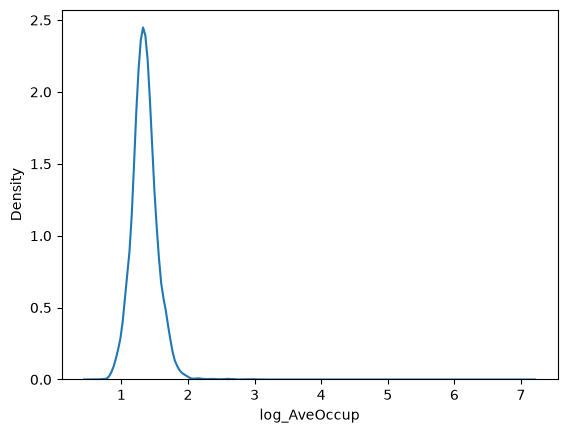

In [ ]:
df_log = df.copy()
df_log[f"log_{col}"] = np.log1p(df_log[col])
sns.kdeplot(df_log[f"log_{col}"])
print(df_log[[col, f"log_{col}"]])

## 8. Domain-Rule Handling

Domain-rule handling means using subject knowledge to decide whether a value is really an outlier.

For example, a very high value may look like an outlier mathematically, but it may still be correct in the real world.

In real projects, always ask:

- Is this value possible?
- Is this value a data entry error?
- Does this value have business meaning?
- Should we remove it, cap it, transform it, or only flag it?


## Final Conclusion

Outliers should not be handled blindly.

In this notebook, we used five common techniques:

1. **Remove outliers** when the values are likely wrong or not useful.
2. **IQR capping** when we want to keep rows but control extreme values.
3. **Outlier flagging** when the unusual value may still carry information.
4. **Percentile capping** when we want simple lower and upper limits.
5. **Log transformation** when the data is right-skewed.

A good practice is to compare results before and after treatment, then choose the method that makes the most sense for the problem.
